# CVP mid-term, round 2: the SHARP CONTROL run (~45 min in total)

Colab → Runtime → Change runtime type → **T4 GPU**. Run cells **1–5, then 8–9**. Cells 6–7 are optional extras for later.

The sharp control trains on the same 30 views but with the *sharp* reference images. Comparing it with round 1 (strong motion, strong defocus) shows how much blur damages each structure type, versus what is hard to rebuild anyway.

Times on a free T4: install 5–10 min · data ~3 min · training ~26 min · scoring ~8–10 min.
On Colab, cell 2 asks for Google Drive access: the finished run is copied to `MyDrive/cvp_runs`.

In [1]:
# 1) GPU check
!nvidia-smi --query-gpu=name,compute_cap,memory.total --format=csv

name, compute_cap, memory.total [MiB]
Tesla T4, 7.5, 15360 MiB


In [2]:
# 2) Get the latest code + a safe place for results
import os
ON_KAGGLE = os.path.isdir("/kaggle/working")
WORK = "/kaggle/working" if ON_KAGGLE else "/content"
os.chdir(WORK)
if not os.path.exists("cvp_project"):
    !git clone -q https://github.com/Saksham-Bali/cvp_project
os.chdir(f"{WORK}/cvp_project")
!git pull -q
# Colab: keep finished runs on Google Drive, so a disconnect does not lose them (a window asks you to allow access)
if ON_KAGGLE:
    BACKUP = "/kaggle/working/cvp_runs_backup"
else:
    from google.colab import drive
    drive.mount("/content/drive")
    BACKUP = "/content/drive/MyDrive/cvp_runs"
os.makedirs(BACKUP, exist_ok=True)
print("finished runs are copied to", BACKUP)
!ls scripts

Mounted at /content/drive
finished runs are copied to /content/drive/MyDrive/cvp_runs
blur_maps.py	     eval_run.py       run_batch.py	   validate_harness.py
compare_scenes.py    gsplat_smoke.py   run_midterm_cpu.py
download_realx3d.py  inspect_scene.py  summarize_runs.py
eval_published.py    make_strata.py    train_gsplat.py


In [3]:
# 3) Install + compile gsplat (5-10 min the first time in a session)
!pip -q install gsplat==1.5.3 ninja jaxtyping rich plyfile huggingface_hub requests lpips
!python scripts/gsplat_smoke.py

Streaming output truncated to the last 5000 lines.
(  ●   ) gsplat: Setting up CUDA with MAX_JOBS=10 (This may take a few minutes 
( ●    ) gsplat: Setting up CUDA with MAX_JOBS=10 (This may take a few minutes 
(●     ) gsplat: Setting up CUDA with MAX_JOBS=10 (This may take a few minutes 
( ●    ) gsplat: Setting up CUDA with MAX_JOBS=10 (This may take a few minutes 
(   ●  ) gsplat: Setting up CUDA with MAX_JOBS=10 (This may take a few minutes 
(    ● ) gsplat: Setting up CUDA with MAX_JOBS=10 (This may take a few minutes 
(     ●) gsplat: Setting up CUDA with MAX_JOBS=10 (This may take a few minutes 
(    ● ) gsplat: Setting up CUDA with MAX_JOBS=10 (This may take a few minutes 
(   ●  ) gsplat: Setting up CUDA with MAX_JOBS=10 (This may take a few minutes 
(  ●   ) gsplat: Setting up CUDA with MAX_JOBS=10 (This may take a few minutes 
( ●    ) gsplat: Setting up CUDA with MAX_JOBS=10 (This may take a few minutes 
(●     ) gsplat: Setting up CUDA with MAX_JOBS=10 (This may take a fe

In [4]:
# 4) Data: strong-motion folder (it also holds the sharp reference images) + the laser scan
SCENE = "Ujikintoki"
!python scripts/download_realx3d.py --what quarter gt --scenes $SCENE --conditions motion_strong

Saving into: /content/cvp_project/data
Scenes: ['Ujikintoki']
Conditions: ['motion_strong']
Parts: ['gt', 'quarter']

[quarter] motion_strong: streaming (keeps only ['Ujikintoki']) ...
    finished Ujikintoki
[quarter] motion_strong: done
[gt] Ujikintoki
  downloading pointclouds/Ujikintoki.tar.gz ...

pointclouds/Ujikintoki.tar.gz: downloading bytes:  83% 213M/256M [00:01<00:00, 274MB/s, 15.6MB/s  ]
pointclouds/Ujikintoki.tar.gz: downloading bytes: 100% 256M/256M [00:01<00:00, 135MB/s, 24.0MB/s  ]
pointclouds/Ujikintoki.tar.gz: reconstructing file: 100% 256M/256M [00:01<00:00, 135MB/s, 24.4MB/s  ]

All done.


In [ ]:
# 5) THE run for the mid-term: sharp control, 7000 steps (same settings as round 1), then scored.
!python scripts/run_batch.py --scene $SCENE --backup $BACKUP --runs motion_strong:sharp:7000:sharp_control


########## motion_strong:sharp:7000:sharp_control  ->  runs/Ujikintoki/motion_strong/sharp_control/s0
Scene Ujikintoki / motion_strong / images=sharp: 30 train views, 5 test views, 1758x1168, 35,314 initial Gaussians, scene scale 3.98 m
step      0/7000  loss 0.2340  #gaussians 35,314  elapsed 0.1 min  eta 384.7 min
step    500/7000  loss 0.0491  #gaussians 35,314  elapsed 1.7 min  eta 21.7 min
step   1000/7000  loss 0.0378  #gaussians 83,669  elapsed 3.4 min  eta 20.4 min
step   1500/7000  loss 0.0316  #gaussians 141,946  elapsed 5.2 min  eta 19.0 min
step   2000/7000  loss 0.0277  #gaussians 192,585  elapsed 7.0 min  eta 17.6 min
step   2500/7000  loss 0.0267  #gaussians 234,836  elapsed 8.9 min  eta 16.0 min
step   3000/7000  loss 0.0280  #gaussians 270,364  elapsed 10.8 min  eta 14.4 min
step   3500/7000  loss 0.0239  #gaussians 259,542  elapsed 12.7 min  eta 12.7 min
step   4000/7000  loss 0.0246  #gaussians 283,145  elapsed 14.6 min  eta 11.0 min
step   4500/7000  loss 0.0214  #

In [ ]:
# 6) OPTIONAL, later (not needed for the mid-term): mild blur, ~35-40 min each
# !python scripts/download_realx3d.py --what quarter --scenes $SCENE --conditions motion_mild defocus_mild
# !python scripts/run_batch.py --scene $SCENE --backup $BACKUP --runs motion_mild:blurred:7000 defocus_mild:blurred:7000

In [5]:
# 7) OPTIONAL, later: strong motion with 30000 steps (~2.5 h)
!python scripts/run_batch.py --scene $SCENE --backup $BACKUP --runs motion_strong:blurred:30000:vanilla_30k


########## motion_strong:blurred:30000:vanilla_30k  ->  runs/Ujikintoki/motion_strong/vanilla_30k/s0
Scene Ujikintoki / motion_strong / images=blurred: 30 train views, 5 test views, 1758x1168, 35,314 initial Gaussians, scene scale 3.98 m
step      0/30000  loss 0.1952  #gaussians 35,314  elapsed 0.1 min  eta 1563.8 min
step    500/30000  loss 0.0264  #gaussians 35,314  elapsed 1.7 min  eta 102.0 min
step   1000/30000  loss 0.0240  #gaussians 58,429  elapsed 3.5 min  eta 100.6 min
step   1500/30000  loss 0.0195  #gaussians 83,382  elapsed 5.3 min  eta 99.7 min
step   2000/30000  loss 0.0155  #gaussians 105,412  elapsed 7.1 min  eta 98.6 min
step   2500/30000  loss 0.0121  #gaussians 125,204  elapsed 8.9 min  eta 97.5 min
step   3000/30000  loss 0.0185  #gaussians 142,782  elapsed 10.7 min  eta 96.3 min
step   3500/30000  loss 0.0240  #gaussians 139,959  elapsed 12.5 min  eta 94.8 min
step   4000/30000  loss 0.0218  #gaussians 154,847  elapsed 14.4 min  eta 93.3 min
step   4500/30000  l

input                   steps   #gauss  PSNRtr  PSNRte     F5  F5pub
sharp                    7000   328219   35.93   33.65  0.777  0.811
motion_strong|30k       30000   253544   22.15   22.01  0.590  0.723
Traceback (most recent call last):
  File "/content/cvp_project/scripts/summarize_runs.py", line 136, in <module>
    main()
    ~~~~^^
  File "/content/cvp_project/scripts/summarize_runs.py", line 115, in main
    lim = max(0.05, np.abs(M).max())
                    ~~~~~~~~~~~~~^^
  File "/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py", line 45, in _amax
    return umr_maximum(a, axis, None, out, keepdims, initial, where)
ValueError: zero-size array to reduction operation maximum which has no identity
outputs/Ujikintoki/ours/fig_blur_damage.png


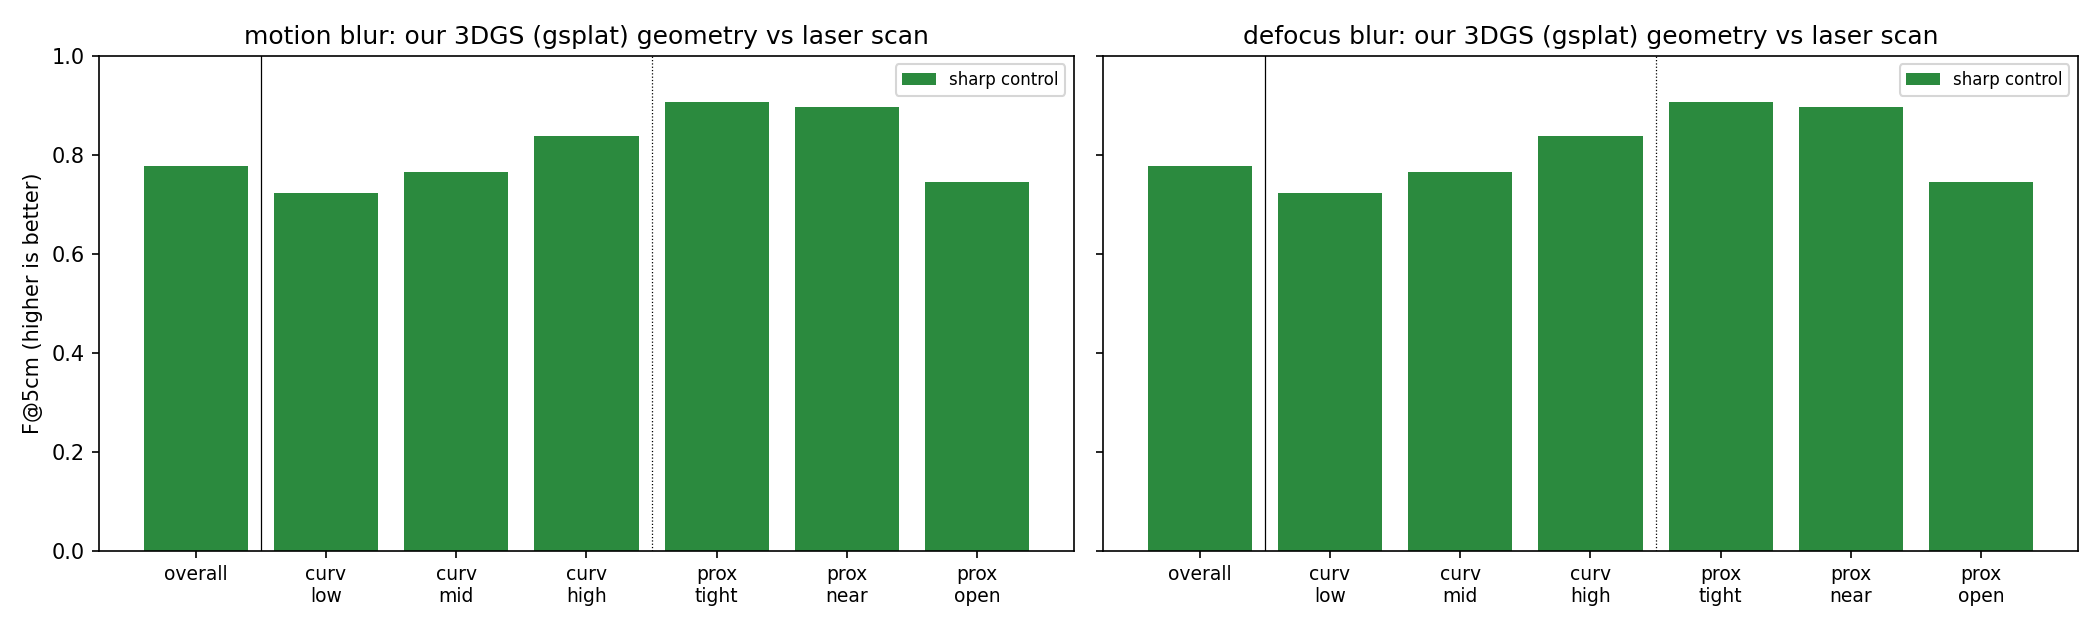

outputs/Ujikintoki/ours/fig_depth_ours_vs_published.png


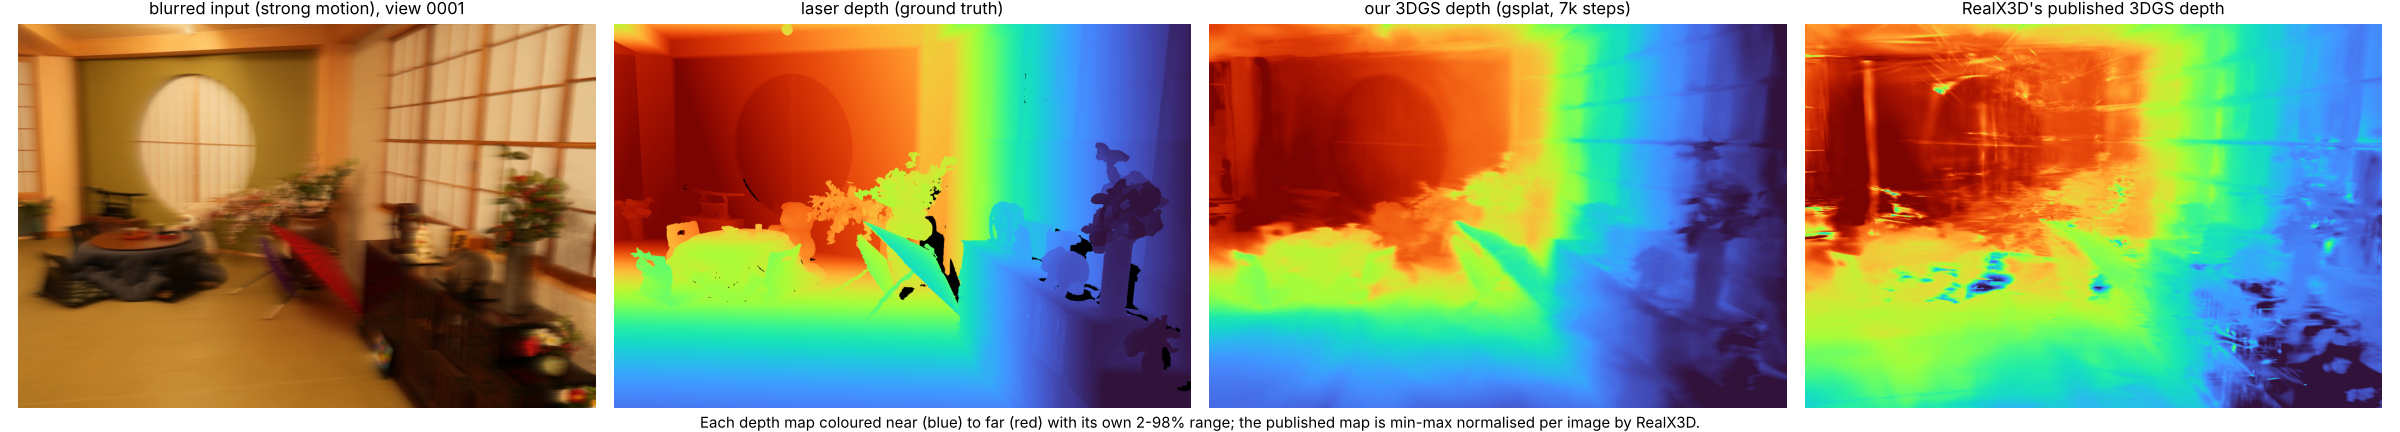

/content/drive/MyDrive/cvp_runs/Ujikintoki/motion_strong/sharp_control/s0/previews/0001_input-render-sharp-depth.jpg


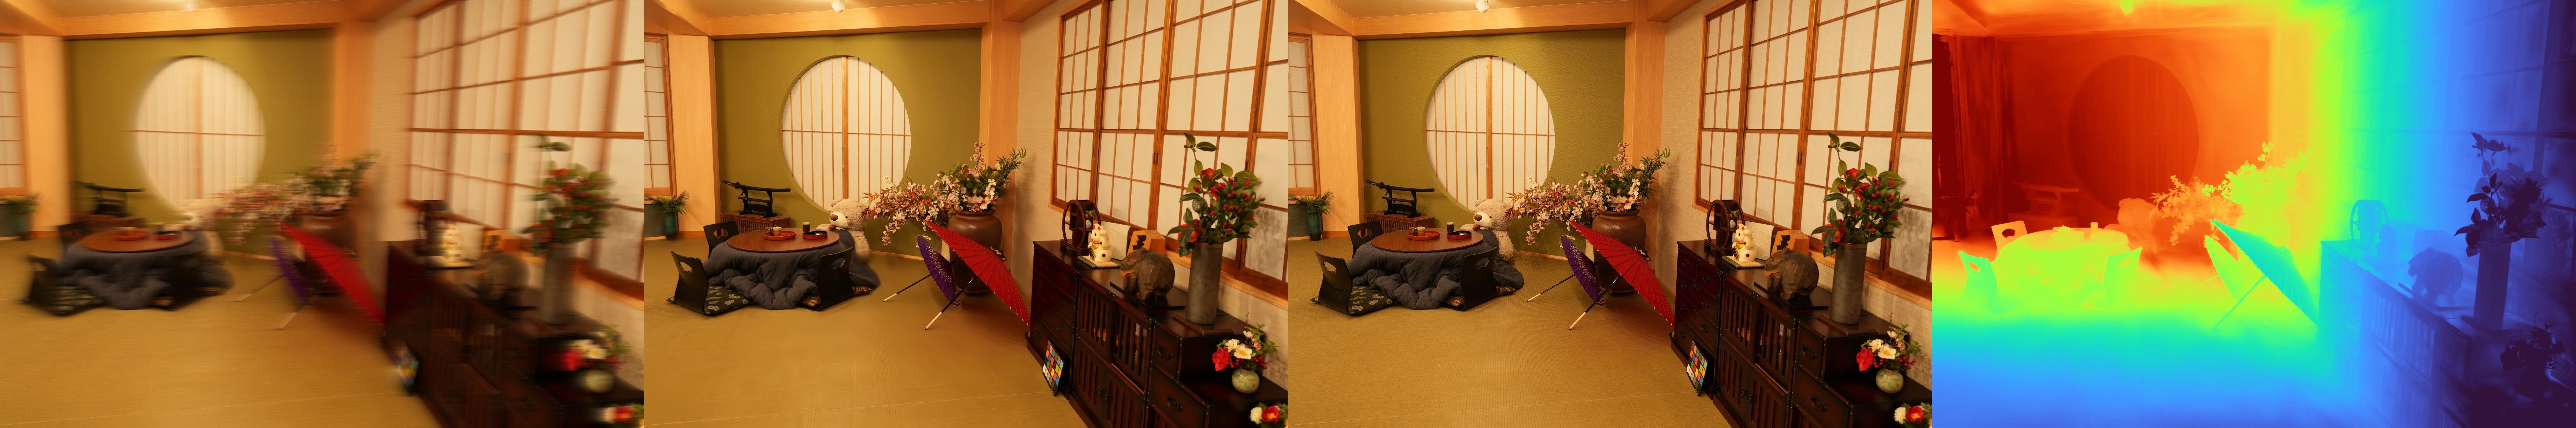

/content/drive/MyDrive/cvp_runs/Ujikintoki/motion_strong/vanilla_30k/s0/previews/0001_input-render-sharp-depth.jpg


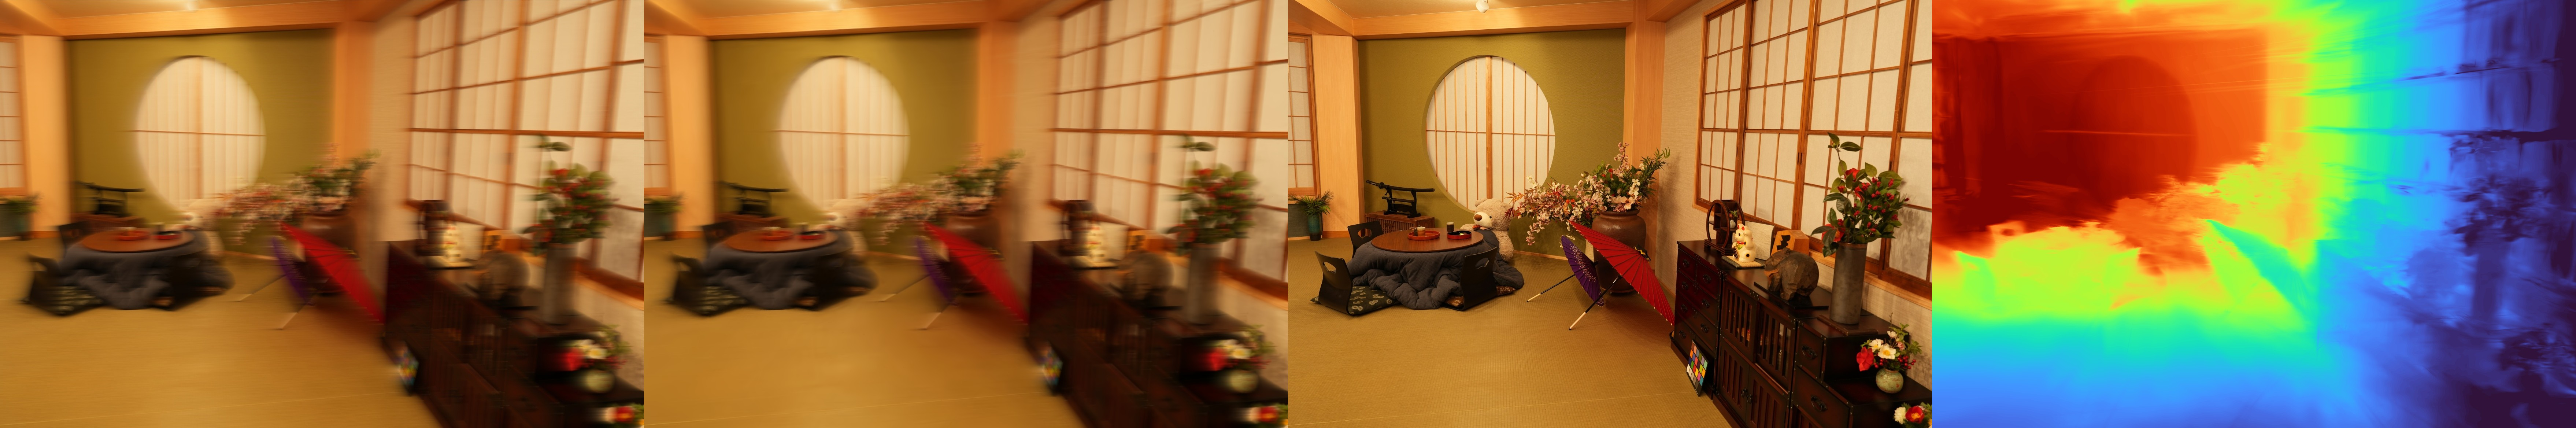

In [6]:
# 8) Table + figures of every finished run (reads BACKUP, so it includes runs from before a disconnect)
!python scripts/summarize_runs.py --scene $SCENE --runs $BACKUP
from IPython.display import Image, display
import glob
for p in sorted(glob.glob(f"outputs/{SCENE}/ours/*.png")) + sorted(glob.glob(f"{BACKUP}/{SCENE}/*/*/s0/previews/*0001*.jpg")):
    print(p); display(Image(p, width=1100))

In [7]:
# 9) Download the results (small files only: metrics, geometry, previews, figures).
#    Inside the zip the runs are under runs/ - extract it into D:\\cvp_project next to the round-1 runs.
import zipfile
with zipfile.ZipFile("cvp_results_round2.zip", "w", zipfile.ZIP_DEFLATED) as z:
    for root, _, files_ in os.walk(BACKUP):
        for f in files_:
            full = os.path.join(root, f)
            z.write(full, os.path.join("runs", os.path.relpath(full, BACKUP)))
    for root, _, files_ in os.walk("outputs"):
        if "gt_cache" in root:
            continue
        for f in files_:
            if not f.endswith((".ply", ".npz")):
                z.write(os.path.join(root, f))
print(round(os.path.getsize("cvp_results_round2.zip") / 1e6, 1), "MB")
try:
    from google.colab import files; files.download("cvp_results_round2.zip")
except Exception:
    print("On Kaggle: download cvp_results_round2.zip from the Output panel (/kaggle/working/cvp_project)")

20.2 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>